## Performance on test set

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import sys

# Setup
sys.path.append(os.getcwd())
from models import BlindFNO 
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

model_dir = 'results_FNO_blind'
config_path = f'{model_dir}/config.json'
weights_path = f'{model_dir}/model_fno.pth'

if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config non trovata in {model_dir}")

# Carica Config
with open(config_path, 'r') as f:
    config = json.load(f)

print(f"Caricamento FNO Blind con parametri: modes={config['modes']}, width={config['width']}")

# Inizializza Modello
model = BlindFNO(
    N_nodes=config["N_NODES"],
    modes=config["modes"],
    width=config["width"]
).to(device)

# Carica Pesi
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()
print(f"✅ Modello FNO caricato.")

# Carica Dati Test (Ultime 100 traiettorie)
try:
    data_full = np.load('data/data_ac_graph_train.npy')
    test_data = data_full[-100:] 
    print(f"Test Data Shape: {test_data.shape}")
except FileNotFoundError:
    raise FileNotFoundError("File dati non trovato.")

Caricamento FNO Blind con parametri: modes=32, width=64
✅ Modello FNO caricato.
Test Data Shape: (100, 21, 1000)


/tmp/ipykernel_3416934/3221530368.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


In [2]:
print("Esecuzione Rollout Autoregressivo...")
preds = []
targets = []

with torch.no_grad():
    for traj in test_data:
        # Stato iniziale t=0
        curr_state = torch.tensor(traj[0], dtype=torch.float32).unsqueeze(0).to(device)
        traj_pred = [curr_state.cpu().numpy()]
        
        # Loop t=1 -> end
        for t in range(1, traj.shape[0]):
            next_state = model(curr_state)
            traj_pred.append(next_state.cpu().numpy())
            curr_state = next_state 
            
        preds.append(np.concatenate(traj_pred, axis=0))
        targets.append(traj)

preds = np.array(preds)   
targets = np.array(targets)

# Calcolo Metriche
mse_per_sample = np.mean((preds - targets)**2, axis=(1, 2))
global_mse = np.mean(mse_per_sample)

norm_diff = np.linalg.norm(preds - targets, axis=(1, 2))
norm_true = np.linalg.norm(targets, axis=(1, 2))
rel_l2_per_sample = norm_diff / (norm_true + 1e-6)
global_rel_l2 = np.mean(rel_l2_per_sample)

print("\n" + "="*50)
print(f"📊 REPORT DI VALUTAZIONE FNO BLIND")
print("="*50)
print(f"MSE Medio:              {global_mse:.6e}")
print(f"L2 Relativa Media:      {global_rel_l2:.4f}  ({global_rel_l2*100:.2f}%)")
print("-" * 50)

Esecuzione Rollout Autoregressivo...

📊 REPORT DI VALUTAZIONE FNO BLIND
MSE Medio:              8.260289e-04
L2 Relativa Media:      0.2655  (26.55%)
--------------------------------------------------


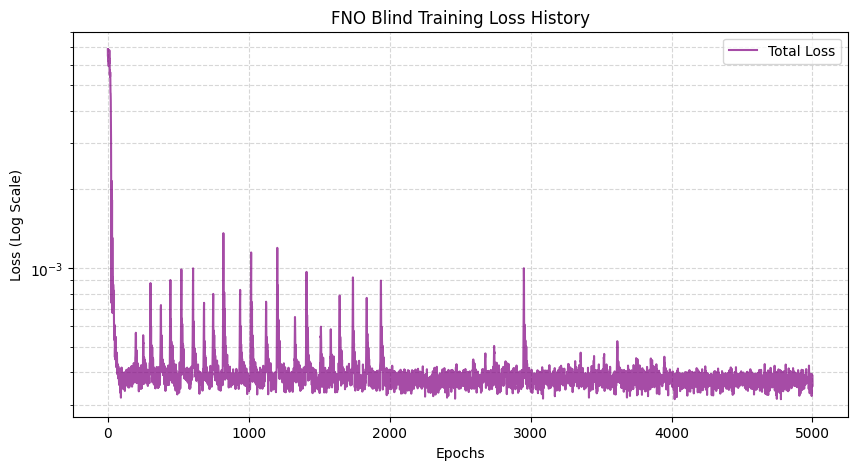

TEST SET RESULTS
Average MSE Error:           8.26e-04
Relative Trajectory Error:   0.2655 ± 0.0110
Accuracy (1 - RelErr):       73.45%


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. LOAD TRAINING HISTORY ---
loss_file_path = os.path.join(model_dir, 'loss_history.npy')

if os.path.exists(loss_file_path):
    loss_history = np.load(loss_file_path)

    # --- 2. PLOT TRAINING HISTORY (Style Requested) ---
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label='Total Loss', color='purple', alpha=0.7)
    plt.yscale('log')
    plt.title('FNO Blind Training Loss History')
    plt.xlabel('Epochs') # Dipende se hai usato iterazioni o epoche nel training
    plt.ylabel('Loss (Log Scale)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
else:
    print(f"⚠️ Attenzione: File loss non trovato in {loss_file_path}")

# --- 3. PRINT METRICS (Format Requested) ---
# Mappiamo le variabili calcolate nella cella precedente ai nomi richiesti dal template
mean_traj_err = global_rel_l2
std_traj_err = np.std(rel_l2_per_sample)
mean_res_error = global_mse # Per il modello Blind, l'MSE è l'unica loss residua

print("="*40)
print("TEST SET RESULTS")
print("="*40)
print(f"Average MSE Error:           {mean_res_error:.2e}")
print(f"Relative Trajectory Error:   {mean_traj_err:.4f} ± {std_traj_err:.4f}")
print(f"Accuracy (1 - RelErr):       {(1-mean_traj_err)*100:.2f}%")
print("="*40)

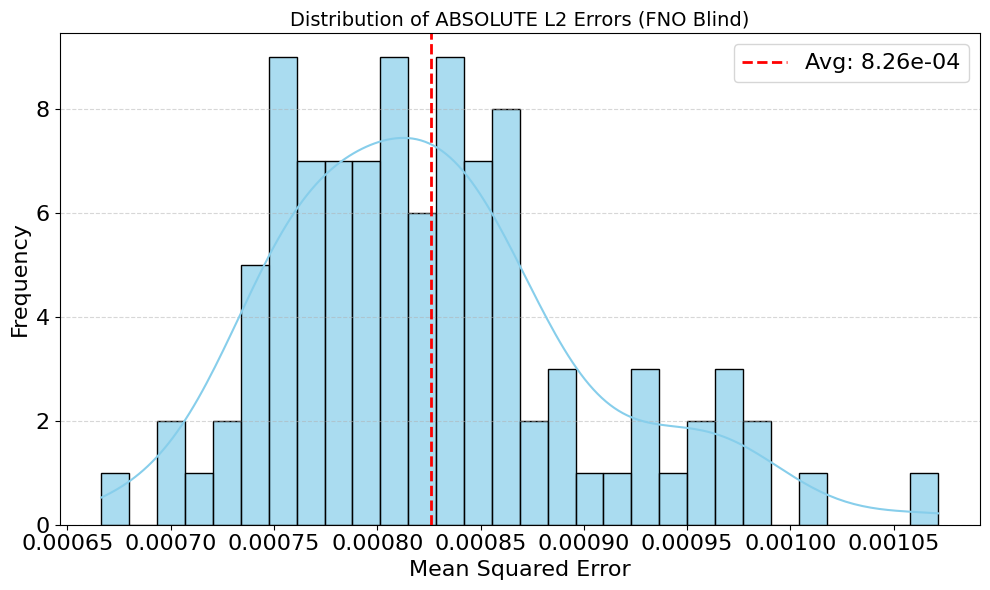

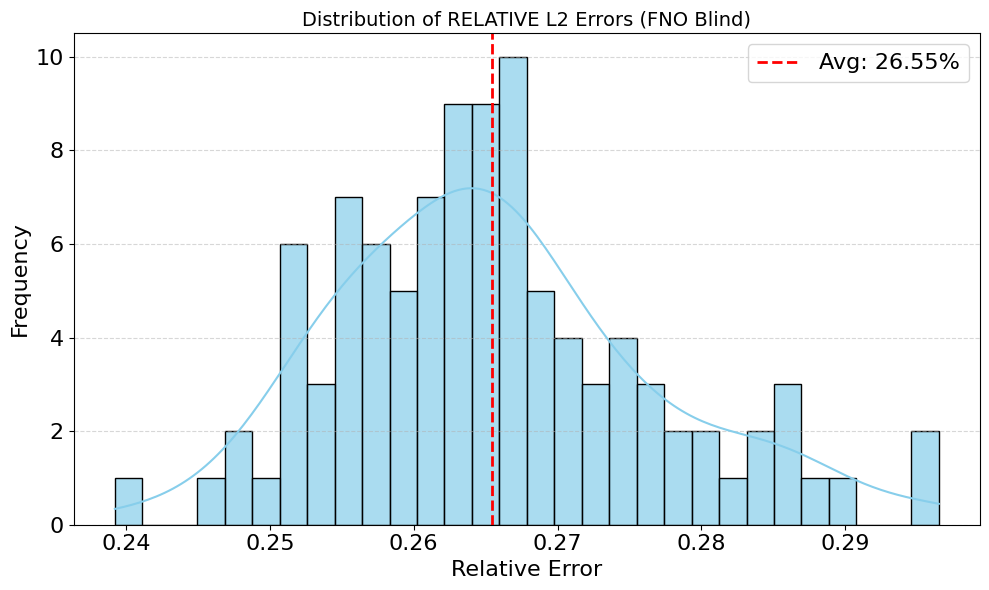

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PLOT 1: Istogramma MSE ---
plt.figure(figsize=(10, 6))
sns.histplot(mse_per_sample, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(global_mse, color='red', linestyle='--', linewidth=2, label=f'Avg: {global_mse:.2e}')

plt.title('Distribution of ABSOLUTE L2 Errors (FNO Blind)', fontsize=14)
plt.xlabel('Mean Squared Error', fontsize=16) # Aumentato font label
plt.ylabel('Frequency', fontsize=16)          # Aumentato font label
plt.legend(fontsize=16)                       # Aumentato font legenda
plt.tick_params(axis='both', which='major', labelsize=16) # Aumentato font numeri assi
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show() 

# --- PLOT 2: Istogramma L2 Relativa ---
plt.figure(figsize=(10, 6))
sns.histplot(rel_l2_per_sample, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(global_rel_l2, color='red', linestyle='--', linewidth=2, label=f'Avg: {global_rel_l2:.2%}')

plt.title('Distribution of RELATIVE L2 Errors (FNO Blind)', fontsize=14)
plt.xlabel('Relative Error', fontsize=16)     # Aumentato font label
plt.ylabel('Frequency', fontsize=16)          # Aumentato font label
plt.legend(fontsize=16)                       # Aumentato font legenda
plt.tick_params(axis='both', which='major', labelsize=16) # Aumentato font numeri assi
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()


Visualizing Sample Index: 10 | Model: Blind FNO
Positives only: Colorbar [0, 1.00]


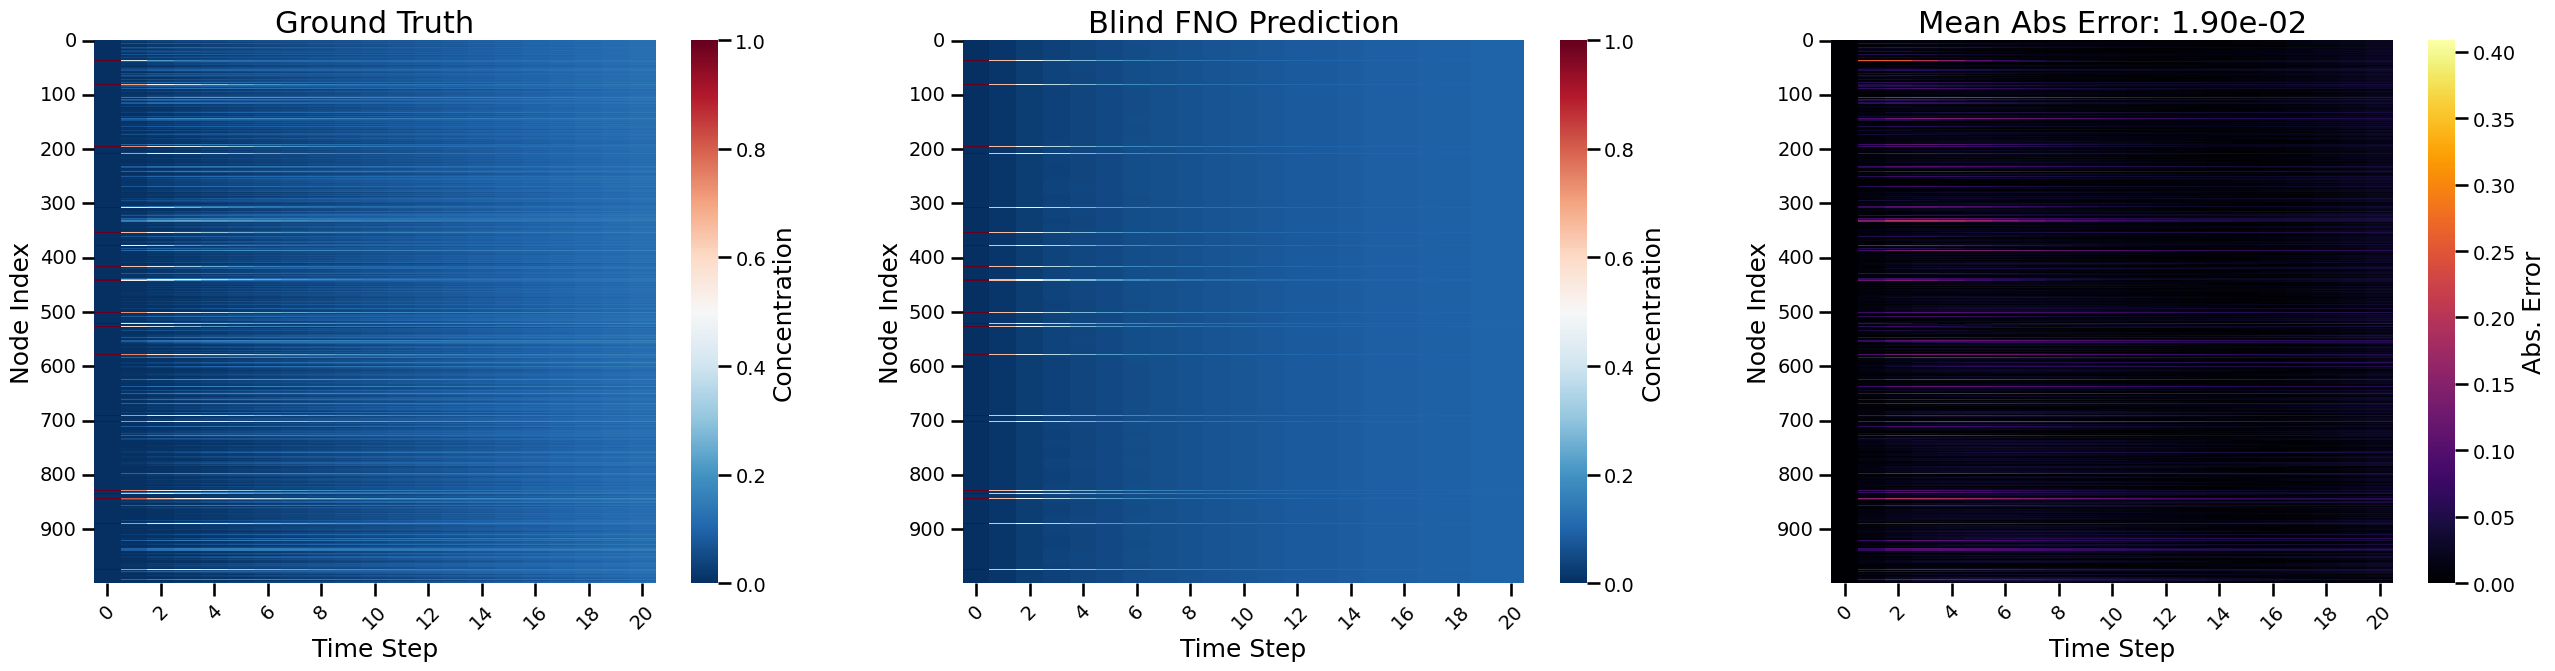

In [5]:
# --- VISUALIZZAZIONE RISULTATI (GOLD STANDARD STYLE) ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CONFIGURAZIONE STILE (FONT GIGANTI & CLEAN)
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})

# 2. SELEZIONE DATI
# Usiamo un indice fisso per coerenza con gli altri plot (es. 10)
sample_idx = 10 
model_name = "Blind FNO"

print(f"\nVisualizing Sample Index: {sample_idx} | Model: {model_name}")

# Estrazione dati (Trasponiamo: X=Tempo, Y=Nodi)
# 'targets' e 'preds' sono già numpy array dal codice precedente
u_true_map = targets[sample_idx].T
u_pred_map = preds[sample_idx].T
u_err_map = np.abs(u_true_map - u_pred_map)

# 3. CALCOLO PASSO PER GLI ASSI (Per evitare sovrapposizioni)
num_nodes = u_true_map.shape[0]
num_time = u_true_map.shape[1]
y_step = max(1, num_nodes // 10) 
x_step = max(1, num_time // 10)

# 4. LOGICA COLORI (Adattiva o Simmetrica)
global_max = max(u_true_map.max(), u_pred_map.max())
global_min = min(u_true_map.min(), u_pred_map.min())

if global_min >= 0:
    # Se i dati sono tutti positivi (es. concentrazioni)
    vmin, vmax = 0.0, global_max 
    print(f"Positives only: Colorbar [0, {vmax:.2f}]")
else:
    # Se ci sono negativi, scala simmetrica
    limit = max(abs(global_min), abs(global_max))
    vmin, vmax = -limit, limit
    print(f"Negatives detected: Colorbar [{-limit:.2f}, {limit:.2f}]")

# 5. SETUP GRAFICO
fig, axes = plt.subplots(1, 3, figsize=(26, 7))

# Helper per parametri comuni
heatmap_args = {
    'vmin': vmin, 'vmax': vmax, 
    'cmap': 'RdBu_r', 
    'cbar': True,
    'xticklabels': x_step,
    'yticklabels': y_step
}

# Plot A: Ground Truth
sns.heatmap(u_true_map, ax=axes[0], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Node Index')

# Plot B: Prediction
sns.heatmap(u_pred_map, ax=axes[1], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[1].set_title(f'{model_name} Prediction') 
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Node Index')

# Plot C: Absolute Error
mae = np.mean(u_err_map)
sns.heatmap(u_err_map, ax=axes[2], cmap='inferno', vmin=0, 
            xticklabels=x_step, yticklabels=y_step,
            cbar=True, cbar_kws={'label': 'Abs. Error'})

# Formattazione scientifica nel titolo
axes[2].set_title(f'Mean Abs Error: {mae:.2e}') 
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Node Index')

# Rotazione tick per leggibilità
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Spaziatura aumentata
plt.tight_layout(w_pad=3.0) 
plt.show()

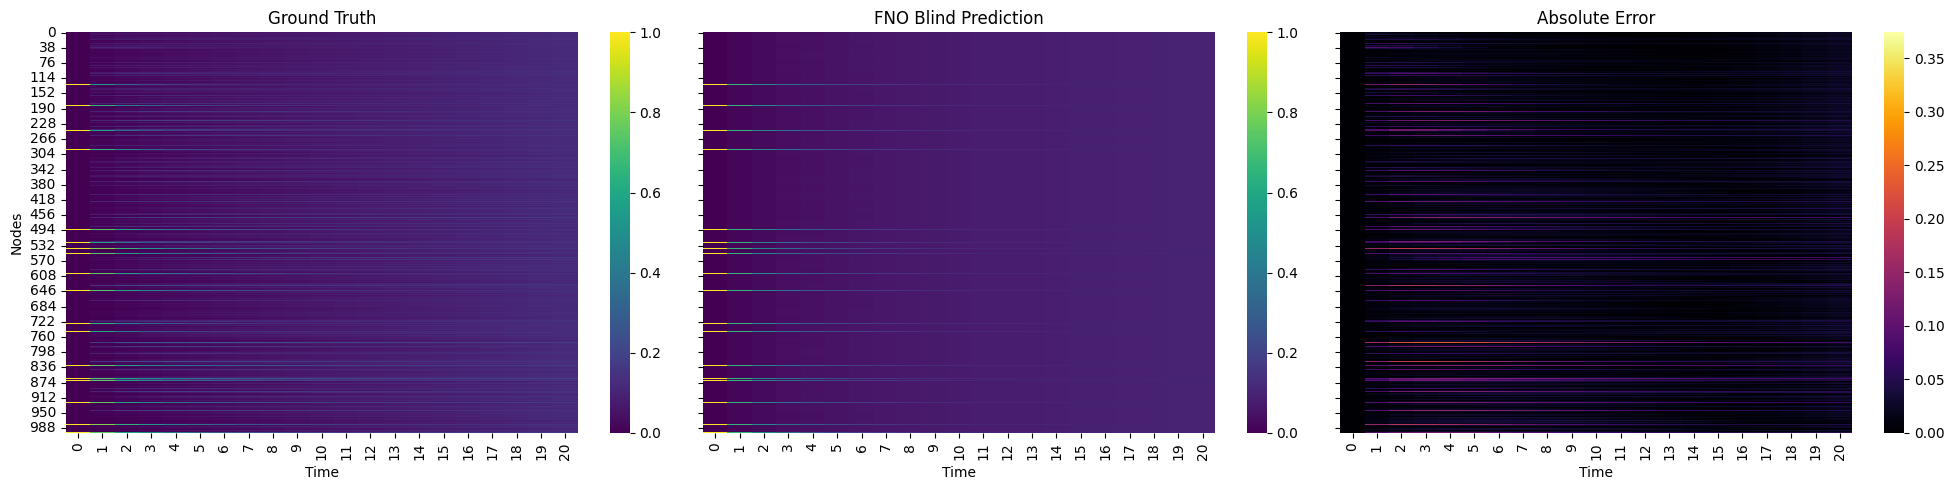

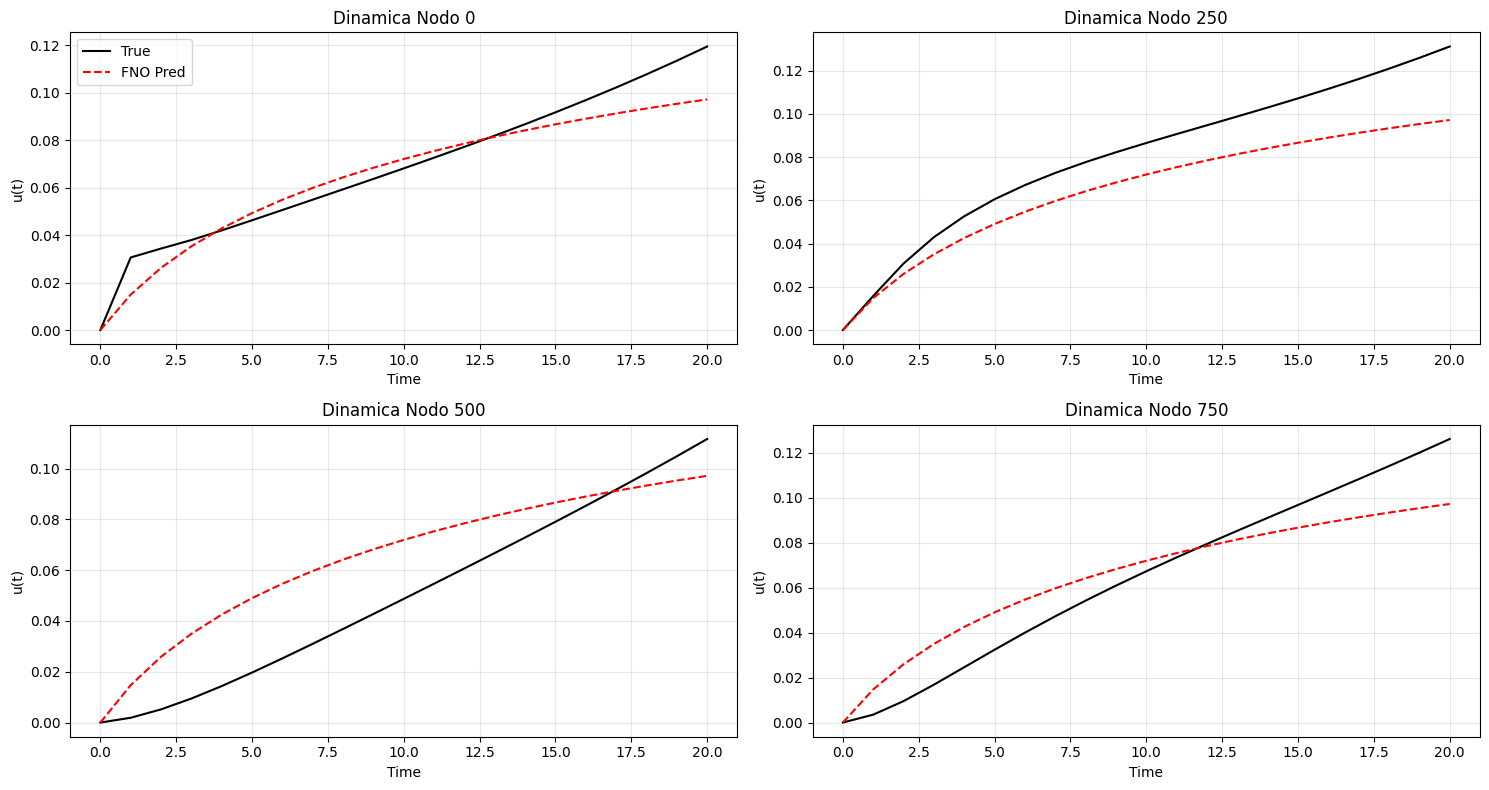

In [5]:
sample_idx = 0 

U_true = targets[sample_idx].T
U_pred = preds[sample_idx].T
U_error = np.abs(U_true - U_pred)

# 1. Heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
vmin, vmax = min(U_true.min(), U_pred.min()), max(U_true.max(), U_pred.max())

sns.heatmap(U_true, ax=axes[0], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground Truth")
axes[0].set_ylabel("Nodes")
axes[0].set_xlabel("Time")

sns.heatmap(U_pred, ax=axes[1], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("FNO Blind Prediction")
axes[1].set_xlabel("Time")

sns.heatmap(U_error, ax=axes[2], cmap="inferno")
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("Time")
plt.tight_layout()
plt.show()

# 2. Plot Dinamica su Nodi specifici
nodes_to_plot = [0, 250, 500, 750]
time_steps = np.arange(targets.shape[1])
plt.figure(figsize=(15, 8))

for i, node_idx in enumerate(nodes_to_plot):
    plt.subplot(2, 2, i+1)
    plt.plot(time_steps, targets[sample_idx, :, node_idx], 'k-', label='True', linewidth=1.5)
    plt.plot(time_steps, preds[sample_idx, :, node_idx], 'r--', label='FNO Pred', linewidth=1.5)
    plt.title(f'Dinamica Nodo {node_idx}')
    if i==0: plt.legend()
    plt.grid(alpha=0.3)
    plt.ylabel("u(t)")
    plt.xlabel("Time")

plt.tight_layout()
plt.show()